<a href="https://www.kaggle.com/code/dianafig/1-0-eda-limpeza?scriptVersionId=319887144" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Análise Preditiva do Mercado Imobiliário de Boston
#### Grupo 10: Diana Figueiredo, Natacha Zhang, Sofia Tanganho
#### Docente: Dora Melo 

In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import kstest, norm

/kaggle/input/datasets/fedesoriano/the-boston-houseprice-data/boston.csv


## Importação do dataset, identificação do tipo de variáveis e análise da qualidade inical dos dados ##

(Diana Figueiredo)

In [2]:
df = pd.read_csv("/kaggle/input/datasets/fedesoriano/the-boston-houseprice-data/boston.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [4]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Verificação de valores nulos

(Sofia Tanganho)


In [5]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

#### Conclusão:
Não foram observados valores nulos no conjunto de dados (_dataset_).

### Verificação de duplicados
(Sofia Tanganho)

In [6]:
df.duplicated().sum()

np.int64(0)

#### Conclusão:
Não foram observados valores duplicados no conjunto de dados (_dataset_).

## Análise exploratória dos dados 


### Histograma de todas as variáveis do _dataset_
(Diana Figueiredo)

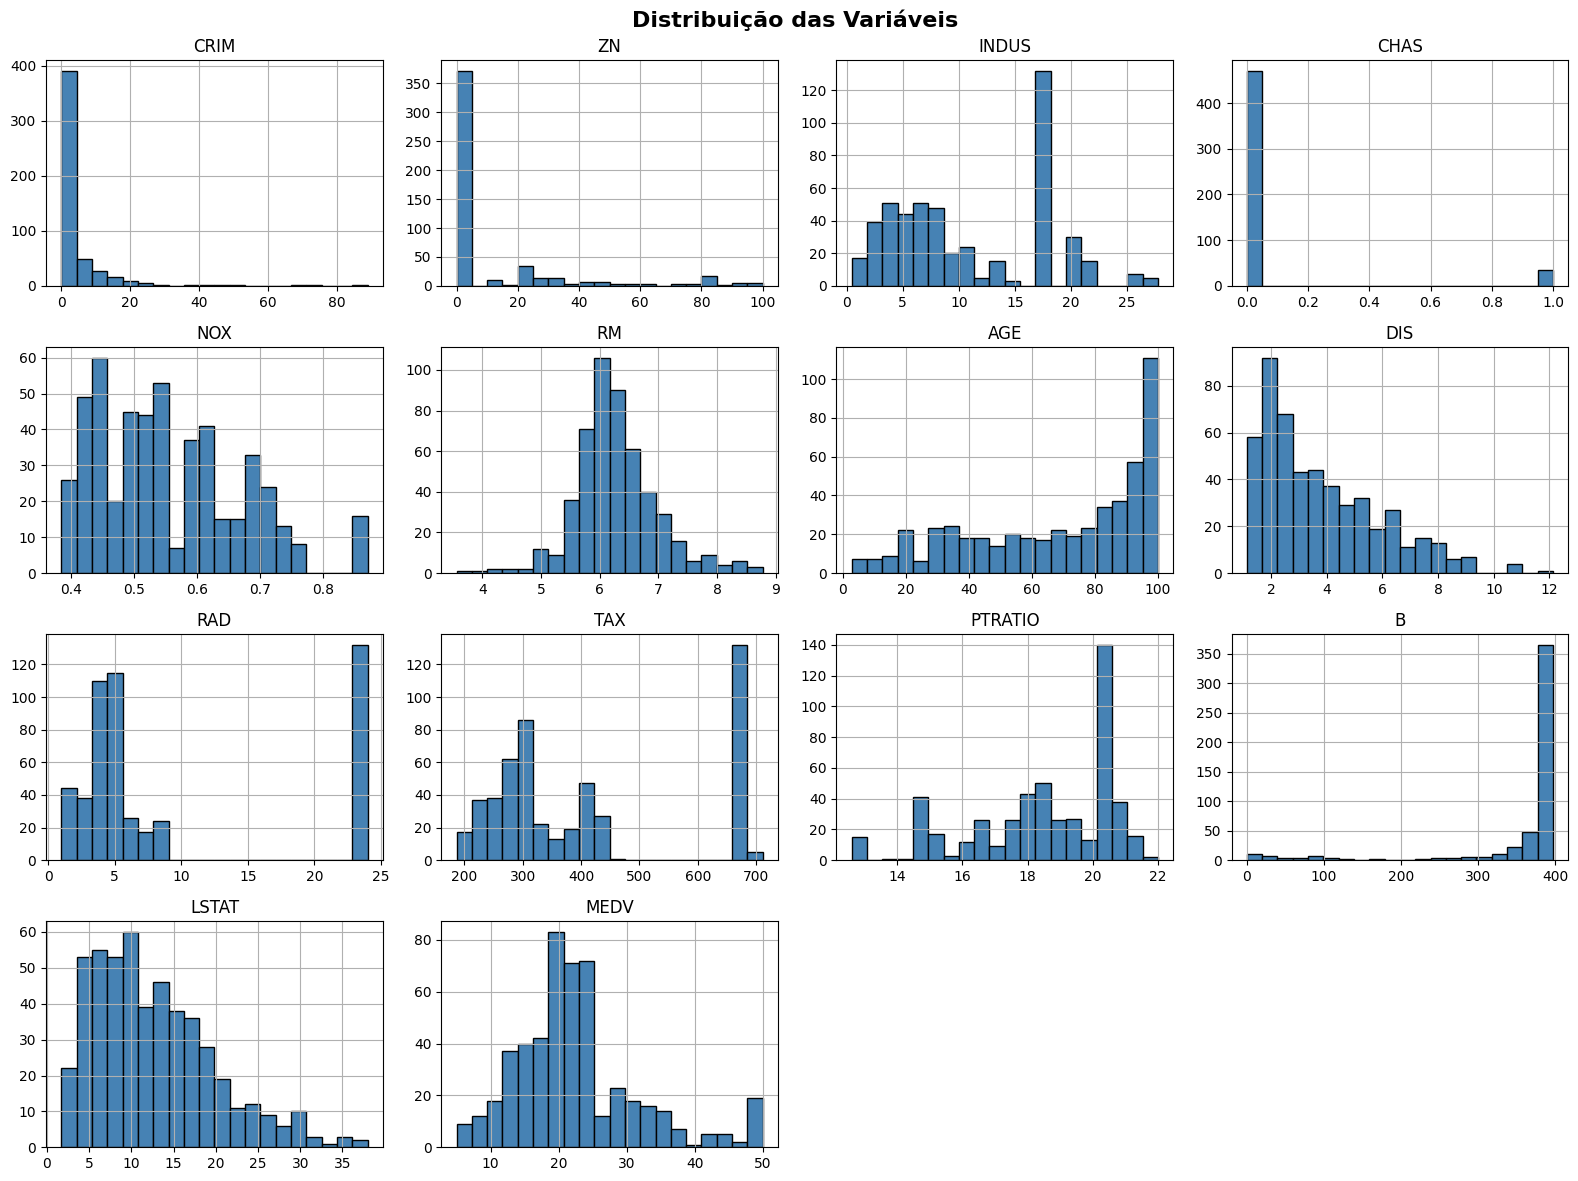

In [7]:
#HISTOGRAMAS
df.hist(figsize=(16, 12), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribuição das Variáveis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('histogramas.png')
plt.show()

In [8]:
#Medidas de Tendência Central
mean_val = df['MEDV'].mean()
median_val = df['MEDV'].median()
mode_val = df['MEDV'].mode()[0]

print(f"Média: {mean_val:.2f}")
print(f"Mediana: {median_val:.2f}")
print(f"Moda: {mode_val:.2f}")

Média: 22.53
Mediana: 21.20
Moda: 50.00


In [9]:
# Kolmogorov-Smirnov
ks_test = kstest(df['MEDV'], 'norm', args=(df['MEDV'].mean(), df['MEDV'].std()))
print(f"Kolmogorov-Smirnov Test: Estatística={ks_test.statistic:.4f}, p-valor={ks_test.pvalue:.4f}")

Kolmogorov-Smirnov Test: Estatística=0.1492, p-valor=0.0000


#### Conclusões:

A análise dos histogramas revelou padrões distintos entre as variáveis do dataset.
**CRIM**, **ZN** e **DIS** apresentam distribuições fortemente assimétricas à
direita, com a maioria dos valores concentrados em valores baixos.
**RAD** e **TAX** exibem uma distribuição bimodal, sugerindo a existência de dois grupos
distintos de habitações. 
**CHAS** é uma variável binária com a grande maioria de valores em 0, indicando que a maioria das habitações não faz fronteira com o rio Charles.
Por sua vez,**RM** é a variável que mais se aproxima de uma distribuição simétrica, enquanto **LSTAT** apresenta uma assimetria moderada à direita. 

Não nos limitámos a utilizar o histograma para analisar a distribuição da variável **MEDV**, pois esta depende da escolha dos intervalos de classe. Calculámos, portanto, as três principais medidas de tendência central. A média (22.53) é superior à mediana (21.20), indicando assimetria positiva, o que já sugere que a variável não segue uma distribuição normal. A moda (50.00) é muito superior às demais medidas, o que poderá indicar um efeito de censura no limite máximo do conjunto de dados (_dataset_).

Esta conclusão é confirmada pelo teste de _Kolmogorov-Smirnov_, uma vez que, o p-valor é inferior ao nível de significância de 0.05, rejeitando-se assim a hipótese nula de normalidade da variável **MEDV**.


### Deteção de outliers
(Natacha Zhang) 

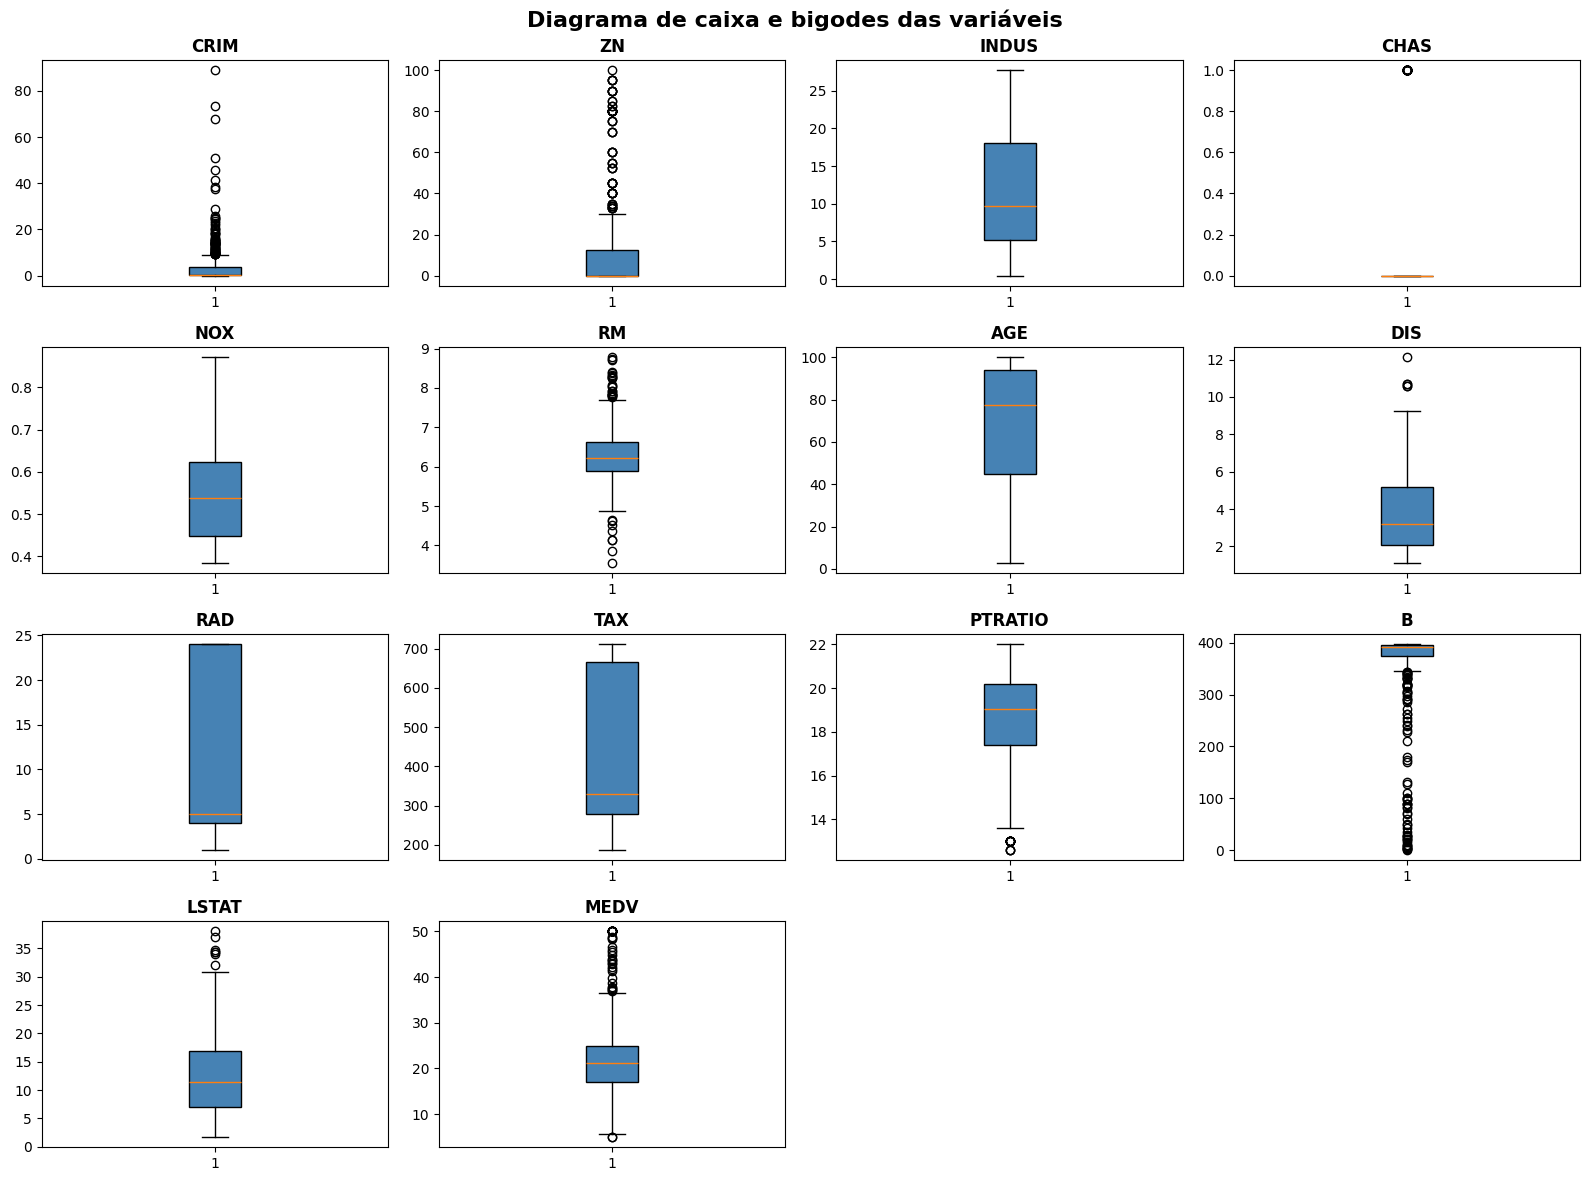

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(df.columns):
    axes[i].boxplot(df[var], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='black'))
    axes[i].set_title(var, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Diagrama de caixa e bigodes das variáveis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

In [11]:
df1 = df.copy()

numericas = df1.columns  

for col in numericas:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inferior = Q1 - 1.5 * IQR
    lim_superior = Q3 + 1.5 * IQR
    
    df1[f'is_outlier_{col}'] = (df1[col] < lim_inferior) | (df1[col] > lim_superior)

for col in numericas:
    print(f"{col} - Número de outliers: {df1[f'is_outlier_{col}'].sum()}")

CRIM - Número de outliers: 66
ZN - Número de outliers: 68
INDUS - Número de outliers: 0
CHAS - Número de outliers: 35
NOX - Número de outliers: 0
RM - Número de outliers: 30
AGE - Número de outliers: 0
DIS - Número de outliers: 5
RAD - Número de outliers: 0
TAX - Número de outliers: 0
PTRATIO - Número de outliers: 15
B - Número de outliers: 77
LSTAT - Número de outliers: 7
MEDV - Número de outliers: 40


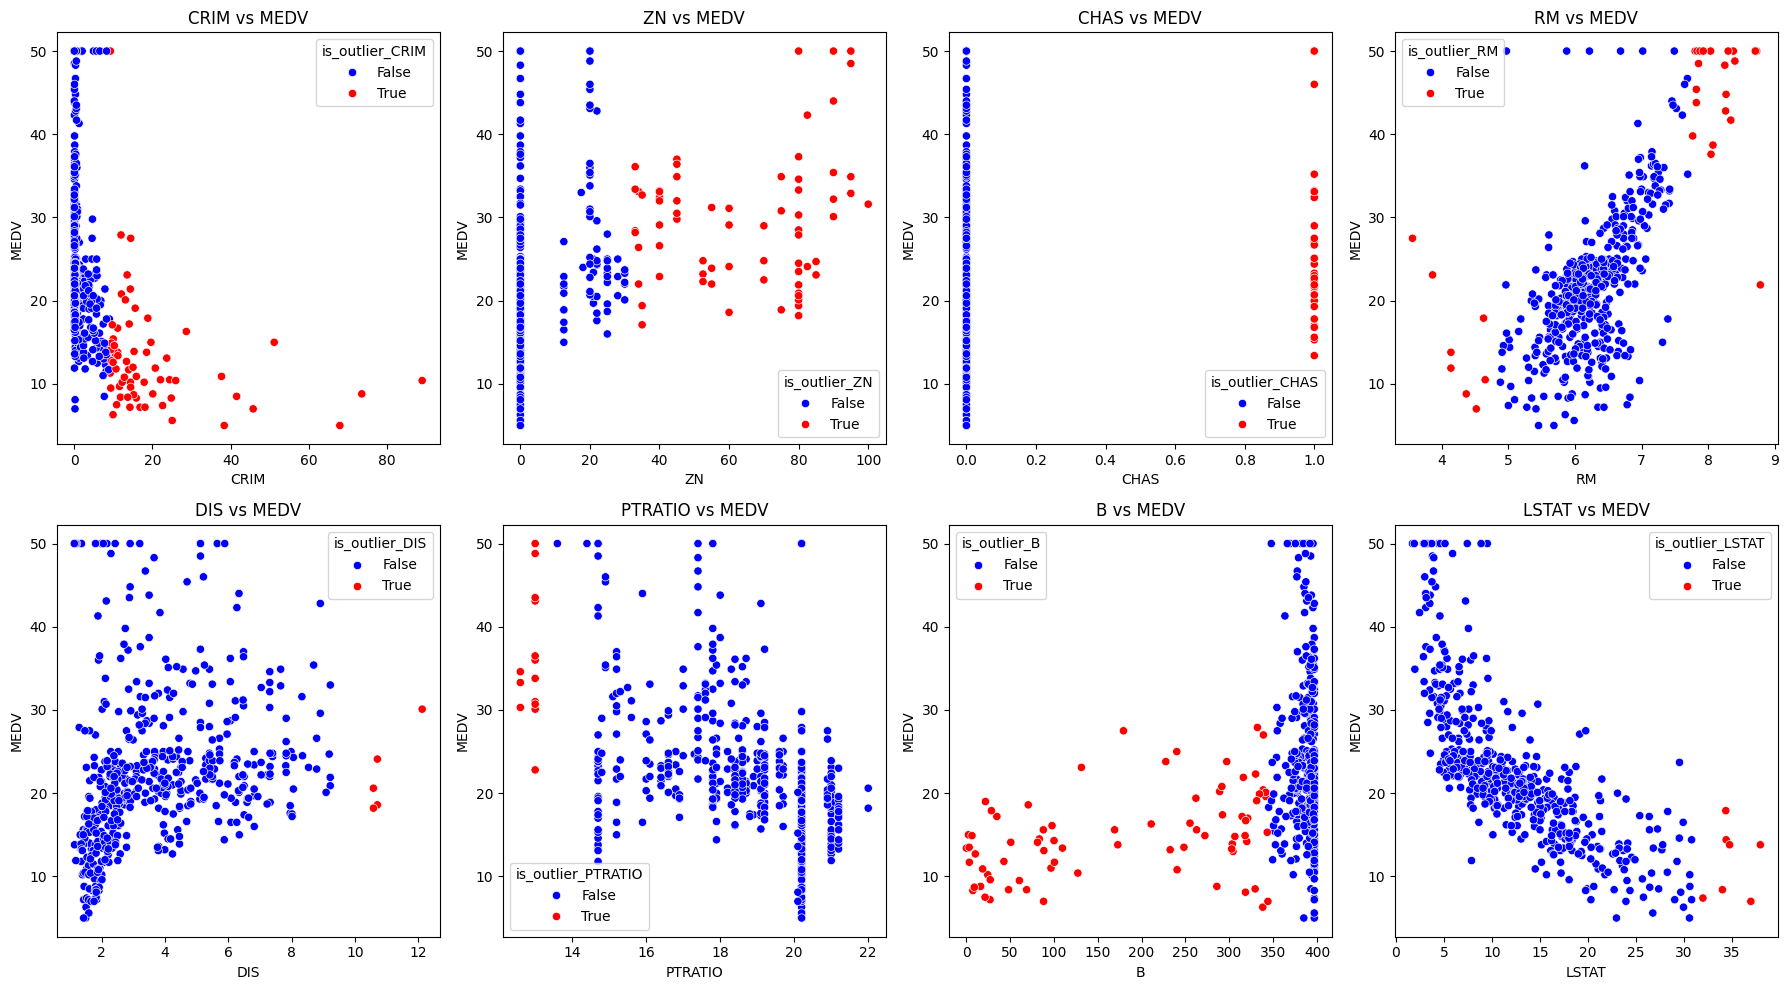

In [12]:
vars_outliers = [col for col in numericas if df1[f'is_outlier_{col}'].sum() > 0 and col != 'MEDV']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))  
axes = axes.flatten() 

for i, var in enumerate(vars_outliers): 
    sns.scatterplot(
        x=df1[var],
        y=df1['MEDV'],
        hue=df1[f'is_outlier_{var}'],
        palette={False:'blue', True:'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{var} vs MEDV')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('MEDV')

plt.tight_layout()
plt.savefig('grafico_dispersao_outliers.png')
plt.show()

In [13]:
vars_outliers = [col for col in numericas if df1[f'is_outlier_{col}'].sum() > 0]

for var in vars_outliers:
    outliers = df1[df1[f'is_outlier_{var}']]
    print(f"\nOutliers da variável {var}:")
    print(outliers[[var, 'MEDV']])
    print('-'*50)


Outliers da variável CRIM:
        CRIM  MEDV
367  13.5222  23.1
371   9.2323  50.0
373  11.1081  13.8
374  18.4982  13.8
375  19.6091  15.0
..       ...   ...
468  15.5757  19.1
469  13.0751  20.1
477  15.0234  12.0
478  10.2330  14.6
479  14.3337  21.4

[66 rows x 2 columns]
--------------------------------------------------

Outliers da variável ZN:
       ZN  MEDV
39   75.0  30.8
40   75.0  34.9
54   75.0  18.9
55   90.0  35.4
56   85.0  24.7
..    ...   ...
351  60.0  24.1
352  60.0  18.6
353  90.0  30.1
354  80.0  18.2
355  80.0  20.6

[68 rows x 2 columns]
--------------------------------------------------

Outliers da variável CHAS:
     CHAS  MEDV
142     1  13.4
152     1  15.3
154     1  17.0
155     1  15.6
160     1  27.0
162     1  50.0
163     1  50.0
208     1  24.4
209     1  20.0
210     1  21.7
211     1  19.3
212     1  22.4
216     1  23.3
218     1  21.5
219     1  23.0
220     1  26.7
221     1  21.7
222     1  27.5
234     1  29.0
236     1  25.1
269     1  20.

#### Conclusões: 

A análise de valores atípicos (_outliers_) através dos diagramas de caixa e bigodes (_boxplots_) e gráficos de dispersão (_scatter plots_), revelou que a maioria das variáveis apresenta valores atípicos (_outliers_).
As variáveis **B** (77), **ZN** (68) e **CRIM** (66) são as que registam maior número de valores atípicos (_outliers_), refletindo a forte assimetria das suas distribuições.

Nos gráficos de dispersão, os valores atípicos (_outliers_) de **CRIM** concentram-se em valores médios baixos de **MEDV**, sugerindo que bairros com criminalidade elevada tendem a apresentar habitações de menor valor. Já os valores atípicos (_outliers_) de **RM** associam-se maioritariamente a valores elevados de **MEDV**, reforçando a relação positiva entre a dimensão da habitação e o seu preço.

Quanto às restantes variáveis, **LSTAT** destaca-se pela relação negativa com **MEDV**, onde os valores atípicos (_outliers_) se situam em valores altos de **LSTAT** e correspondem a habitações de menor valor. A variável **ZN** apresenta valores atípicos (_outliers_) para valores superiores a cerca de 30 da proporção de terrenos residenciais com lotes acima de 25.000 pés quadrados. A variável **CHAS** apresenta valores atípicos (_outliers_) no valor 1, ou seja, em bairros que fazem fronteira com o rio Charles. A variável **B** apresenta a maior concentração de valores atípicos (_outliers_), maioritariamente em valores inferiores a 350, associados a valores de **MEDV** reduzido. A variável **DIS** apresenta valores atípicos (_outliers_) para valores de **DIS** superiores a 10 e a variável **PTRATIO** para valores inferiores a 14.

Relativamente à variável alvo **MEDV**, os 40 valores atípicos (_outliers_) identificados distribuem-se ao longo de vários valores da variável.

### Análise das correlações dos dados
(Sofia Tanganho)

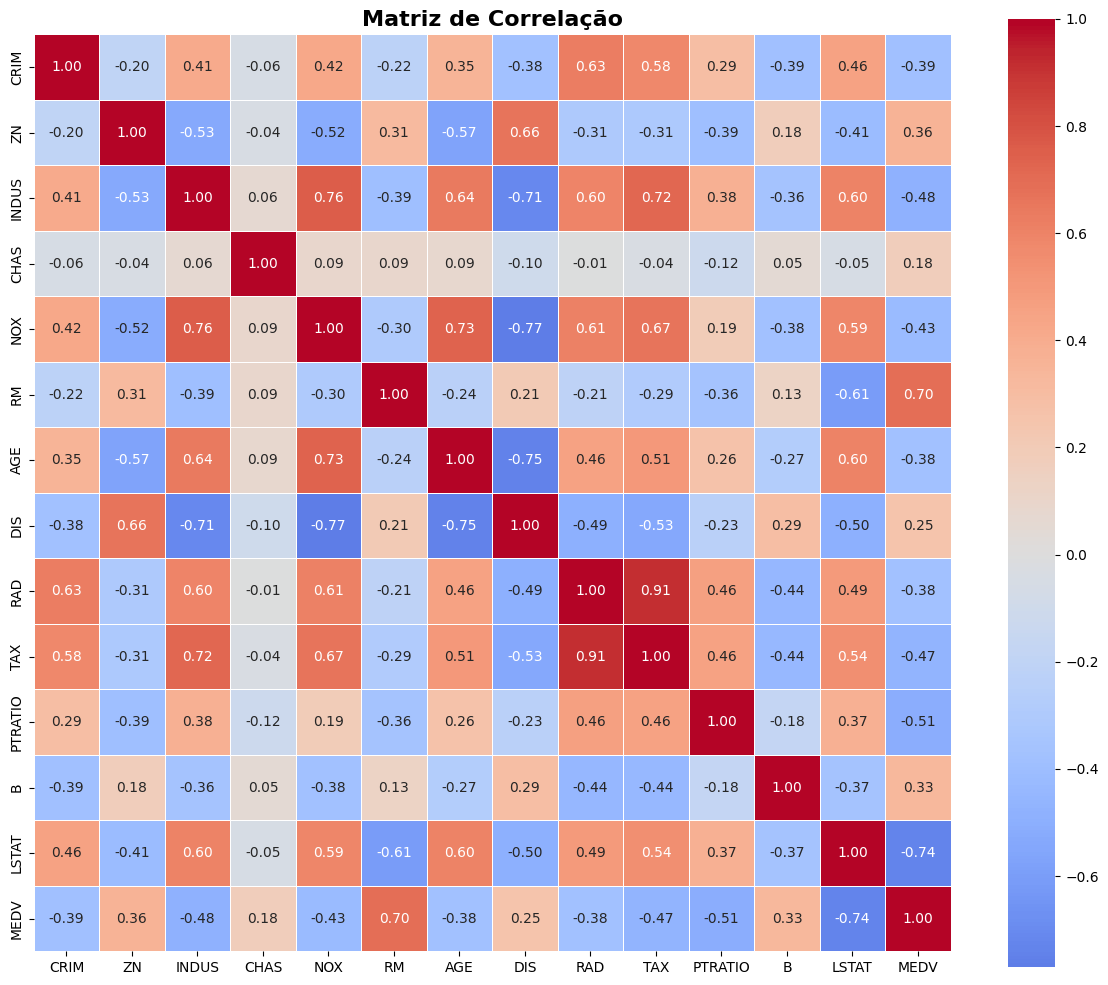

In [14]:
plt.figure(figsize=(12, 10))
correlacao = df.corr()

sns.heatmap(correlacao, 
            annot=True,      
            fmt='.2f',         
            cmap='coolwarm',    
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Matriz de Correlação', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_correlacao.png')
plt.show()

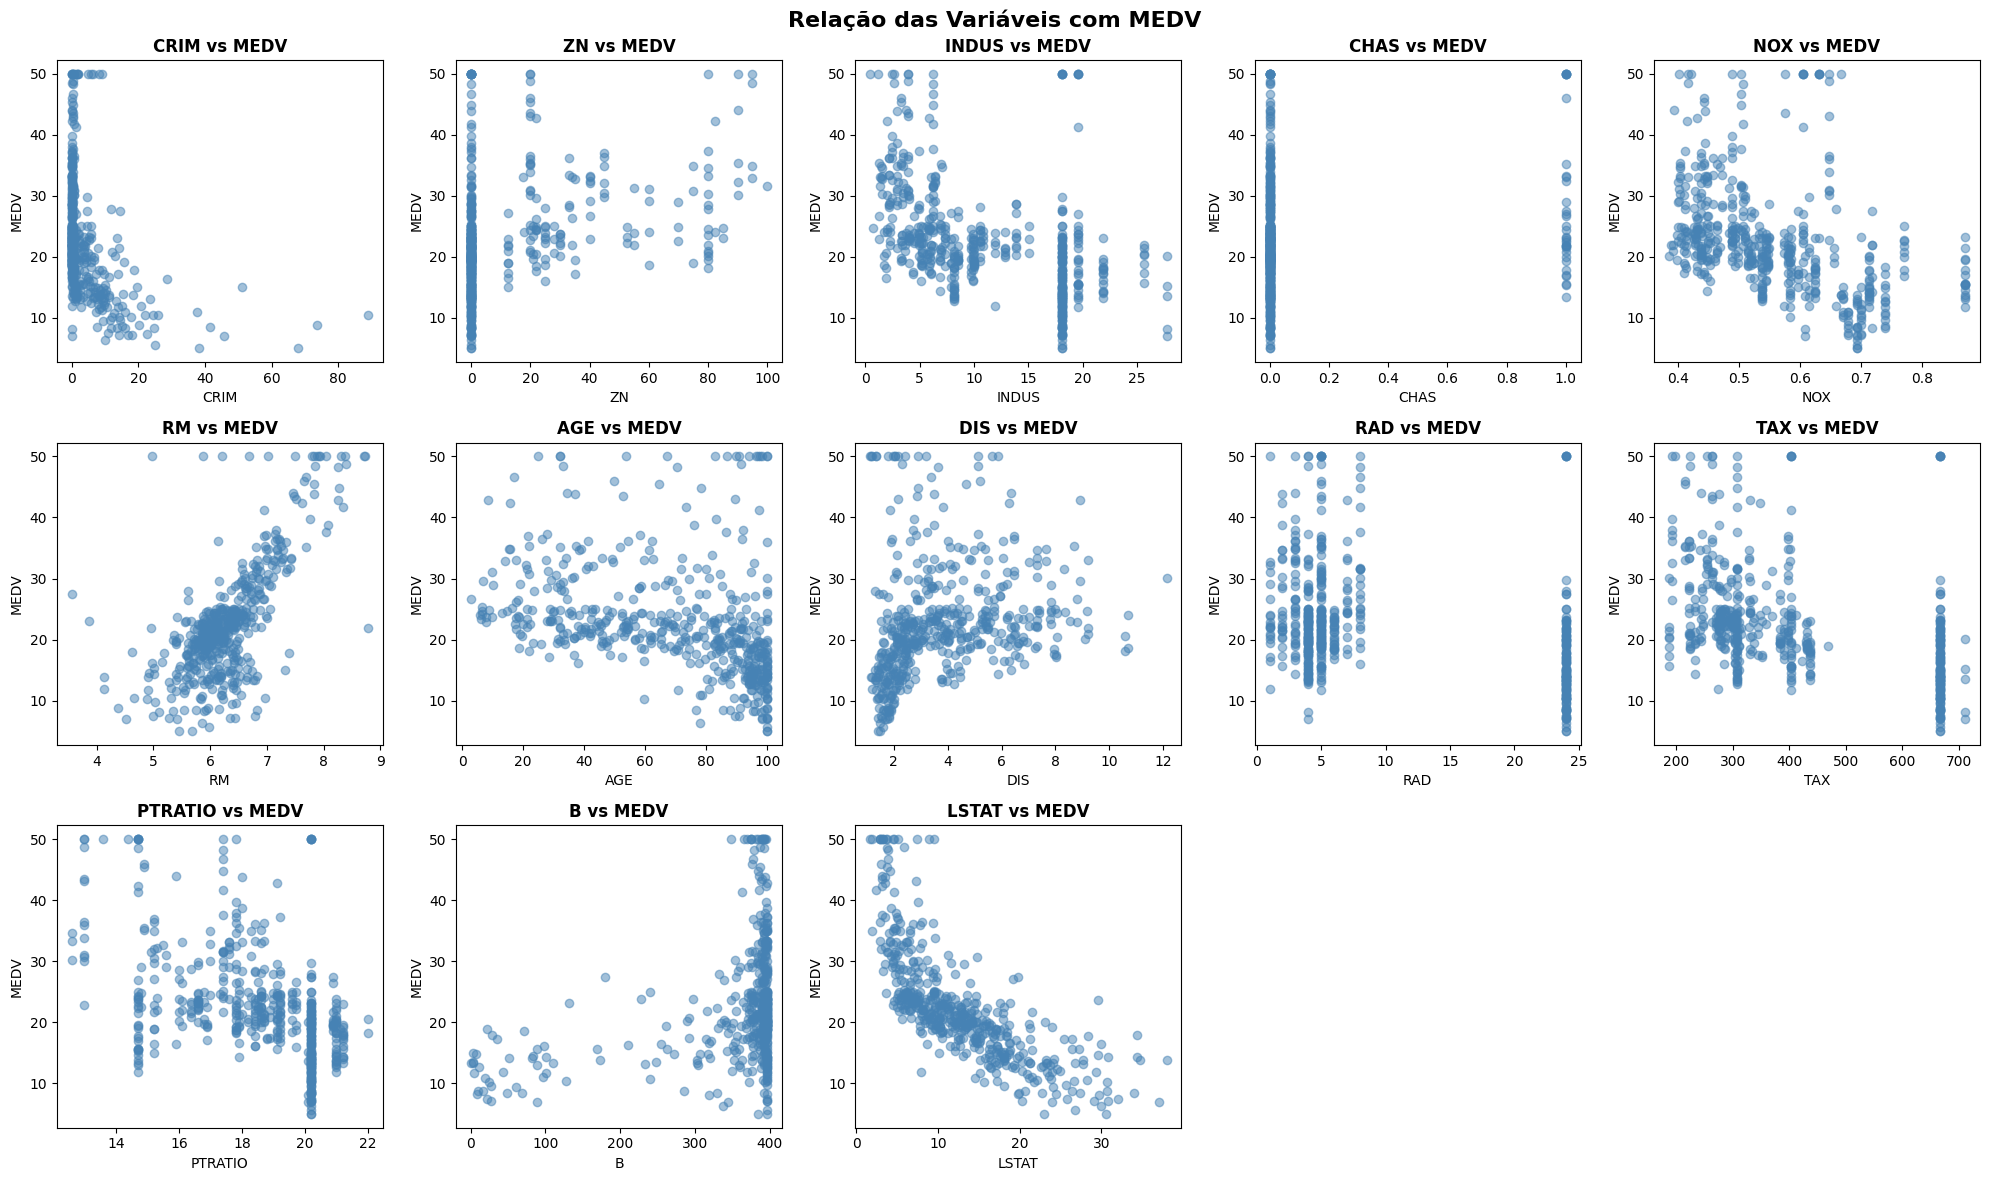

In [15]:
variaveis = [col for col in df.columns if col != 'MEDV']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    axes[i].scatter(df[var], df['MEDV'], alpha=0.5, color='steelblue')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('MEDV')
    axes[i].set_title(f'{var} vs MEDV', fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relação das Variáveis com MEDV', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('graficos_dispersao.png')
plt.show()

#### Conclusões:

A análise do mapa de correlação (_heatmap_) revelou a existência de correlações elevadas entre algumas variáveis independentes, nomeadamente **RAD** e **TAX** (0.91) e **NOX** e **DIS** (-0.77), o que poderá indicar multicolinearidade a considerar na construção do modelo de regressão.

Relativamente à relação com a variável alvo **MEDV**, **LSTAT** apresenta a correlação negativa mais forte (-0.74),indicando que bairros com maior percentagem de população de baixo estatuto socioeconómico tendem a apresentar habitações de menor valor.
**RM** apresenta a correlação positiva mais forte (0.70), sugerindo que habitações com maior número de divisões tendem a ter preços mais elevados. Por fim, **PTRATIO** apresenta uma correlação negativa moderada (-0.51), associando um rácio aluno-professor mais elevado a preços mais baixos.

### Escalonamento 
(Diana Figueiredo) 

In [16]:
standard_vars = ['CRIM','RM','LSTAT','DIS','PTRATIO','B','ZN'] 
normalize_vars = ['INDUS','NOX','AGE','RAD','TAX']              

scaler = StandardScaler()
df_standard = scaler.fit_transform(df[standard_vars])

for i, col in enumerate(standard_vars):
    df[f'{col}_stand'] = df_standard[:, i]

normalizer = MinMaxScaler()
df_normalized = normalizer.fit_transform(df[normalize_vars])

for i, col in enumerate(normalize_vars):
    df[f'{col}_norm'] = df_normalized[:, i]

print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  ...  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0  ...   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0  ...   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0  ...   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0  ...   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0  ...   

   LSTAT_stand  DIS_stand  PTRATIO_stand   B_stand  ZN_stand  INDUS_norm  \
0    -1.075562   0.140214      -1.459000  0.441052  0.284830    0.067815   
1    -0.492439   0.557160      -0.303094  0.441052 -0.487722    0.242302   
2    -1.208727   0.557160      -0.303094  0.396427 -0.487722    0.242302   
3    -1.361517   1.077737       0.113032  0.416163 -0.487722    0.063050   
4    -1.026501   1.077737       0.113032  0.441052 -0.487722    0.063050   

   NOX_norm  AGE_norm  RAD_norm  TAX_norm  
0  0.314815  0.641607  0.00000

#### Observações: 

As variáveis foram escalonadas com dois métodos distintos consoante a sua distribuição. As variáveis com valores atípicos (_outliers_) (**CRIM**, **RM**, **LSTAT**, **DIS**, **PTRATIO**, **B**, **ZN**) foram padronizadas com _StandardScaler_, por ser menos sensível à presença de valores atípicos (_outliers_). As restantes (**INDUS**, **NOX**, **AGE**, **RAD**, **TAX**) foram normalizadas com _MinMaxScaler_, adequado para distribuições mais uniformes.

## Novas Variáveis
(Natacha Zhang)

In [17]:
# Criação de Novos Atributos

# 1. Índice de Qualidade de Vida (IQV)
# Combina criminalidade, qualidade do ar e educação num só índice
df['IQV'] = (1 / df['CRIM']) + (1 / df['NOX']) + (1 / df['PTRATIO'])

# 2. Índice de Atratividade Habitacional (IAH)
# Relaciona o tamanho da habitação com a peso socioeconómico e a distancia a centros de emprego
df['IAH'] = df['RM'] / (df['LSTAT'] * df['DIS'])

print(df[['IQV']].head())
print(df[['IQV']].describe())
print(df['IAH'].head())
print(df['IAH'].describe())


          IQV
0  160.151944
1   38.805000
2   38.831835
3   33.129684
4   16.719141
              IQV
count  506.000000
mean    11.679929
std     16.242551
min      1.446206
25%      1.883696
50%      5.739009
75%     14.532372
max    160.151944
0    0.322807
1    0.141434
2    0.358937
3    0.392642
4    0.221190
Name: IAH, dtype: float64
count    506.000000
mean       0.222874
std        0.214639
min        0.029853
25%        0.123168
50%        0.166978
75%        0.235522
max        2.196409
Name: IAH, dtype: float64


In [18]:
# Remover as variáveis originais e as respetivas escalonadas utilizadas na criação do IQV e do IAH e a variável RAD
df = df.drop(columns=['CRIM', 'NOX', 'PTRATIO', 'RM', 'LSTAT', 'DIS','RAD','CRIM_stand','NOX_norm','PTRATIO_stand','RM_stand','LSTAT_stand','DIS_stand','RAD_norm'])

# Verificar se foram removidas corretamente
print(df.columns)
print(df.shape)  

Index(['ZN', 'INDUS', 'CHAS', 'AGE', 'TAX', 'B', 'MEDV', 'B_stand', 'ZN_stand',
       'INDUS_norm', 'AGE_norm', 'TAX_norm', 'IQV', 'IAH'],
      dtype='object')
(506, 14)


#### Observações: 

A remoção das variáveis utilizadas na criação das novas variáveis deve-se ao facto de evitar a dependência entre variáveis, o que poderia levar a problemas de multicolinearidade. Pelo mesmo motivo, a variável **RAD** foi removida do modelo, uma vez que apresenta uma correlação de 0.91 com a variável **TAX**. A opção de manter a variável **TAX** e remover a variável **RAD** justifica-se pelo facto de este apresentar uma correlação mais elevada com a variável alvo **MEDV** (-0.47) comparativamente ao **RAD** (-0.38), tornando-o mais relevante para a capacidade preditiva do modelo.

### Matriz de correlação 
(Sofia Tanganho)

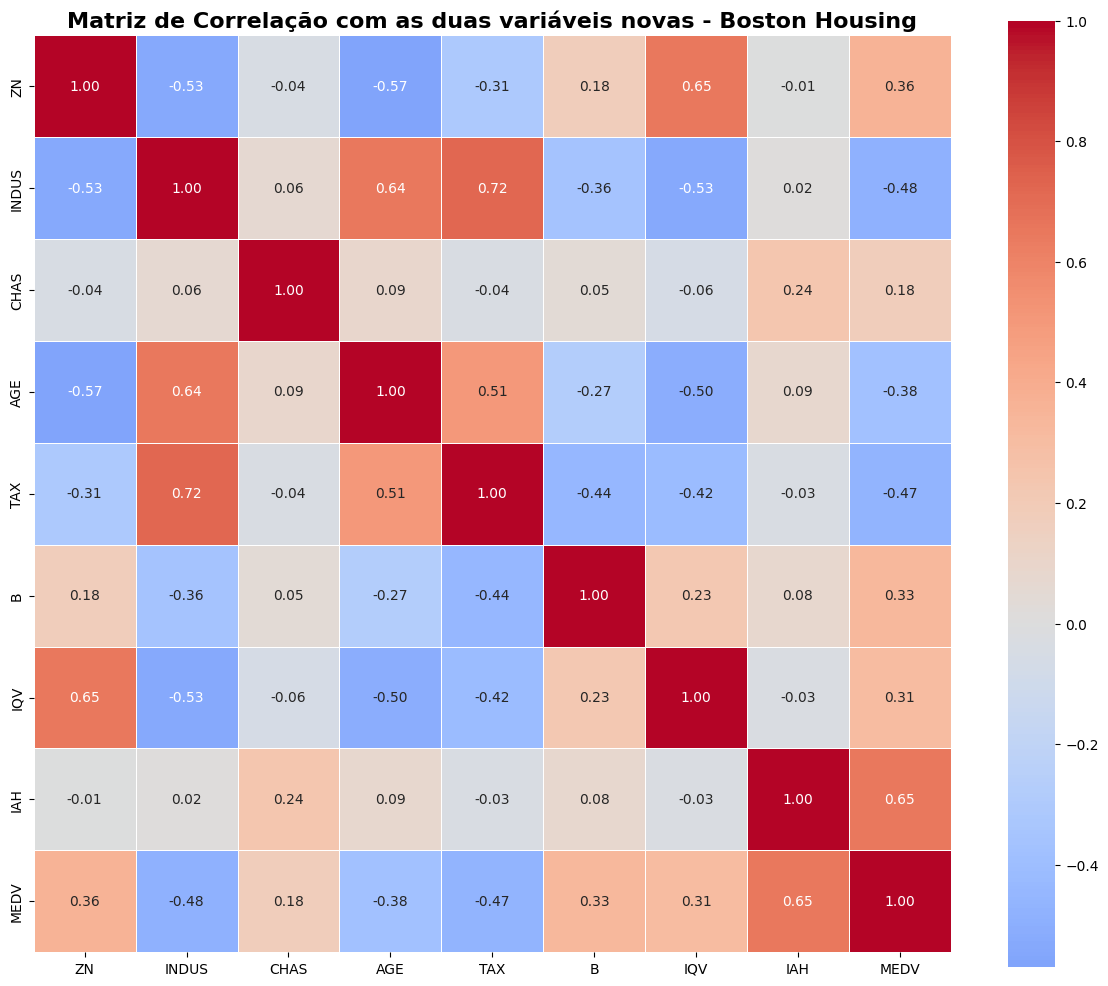

In [19]:
colunas = ['ZN', 'INDUS', 'CHAS', 'AGE', 'TAX', 'B', 'IQV', 'IAH', 'MEDV']

df2 = df[colunas].copy()

plt.figure(figsize=(12, 10))

correlacao = df2.corr()

sns.heatmap(correlacao, 
            annot=True,      
            fmt='.2f',         
            cmap='coolwarm',    
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Matriz de Correlação com as duas variáveis novas - Boston Housing', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_correlacao_nova_variavel.png')
plt.show()

#### Conclusões: 

O **IAH** apresentou uma correlação de 0.65 com o **MEDV**,a mais elevada das duas novas variáveis. Contudo, este valor deve ser interpretado com cautela, uma vez que o índice incorpora o **RM** e o **LSTAT**, variáveis que individualmente já apresentavam correlações de 0.70 e -0.74 com o **MEDV**, respetivamente. Desta forma, o poder preditivo do **IAH** é, em grande parte, explicado pela forte relação que as suas variáveis constituintes já estabeleciam com a variável alvo.
O **IQV**, por sua vez, obteve uma correlação positiva fraca com o **MEDV** (0.31). Ainda assim, este índice agrega de forma coerente três variáveis ( **CRIM**, **NOX** e **PTRATIO**) que individualmente apresentavam correlações de -0.39, -0.43 e -0.51 com o **MEDV**, respetivamente. A combinação destas variáveis através do seu inverso permite construir um indicador mais interpretável de qualidade de vida urbana, ainda que o seu impacto no preço dos imóveis seja moderado.
De forma geral, a introdução destas duas novas variáveis contribui para uma melhor caracterização do conjunto de dados, sendo importante considerar a influência das variáveis originais na interpretação dos resultados obtidos.

### Diagrama de caixa e bigodes (_Boxplot_) das novas variáveis 
(Sofia Tanganho)

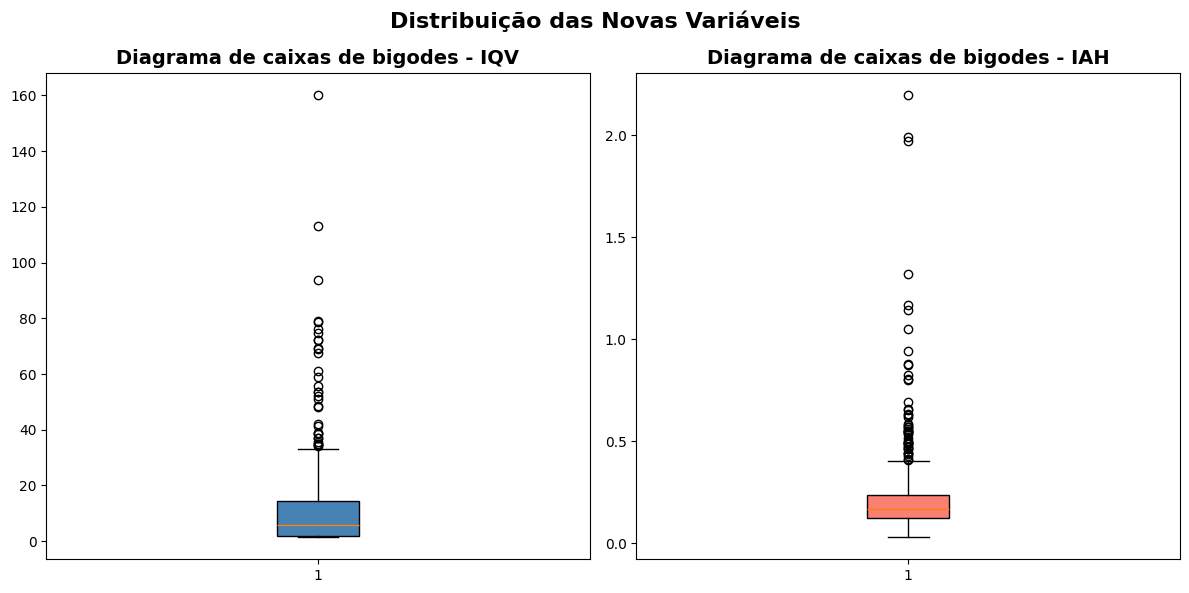

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Boxplot IQV
axes[0].boxplot(df['IQV'], patch_artist=True, boxprops=dict(facecolor='steelblue', color='black'))
axes[0].set_title('Diagrama de caixas de bigodes - IQV', fontsize=14, fontweight='bold')

# Boxplot IAH
axes[1].boxplot(df['IAH'], patch_artist=True, boxprops=dict(facecolor='salmon', color='black'))
axes[1].set_title('Diagrama de caixas de bigodes - IAH', fontsize=14, fontweight='bold')


plt.suptitle('Distribuição das Novas Variáveis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_nova_variavel.png')
plt.show()

#### Conclusões:

Os diagramas de caixas de bigodes (_boxplots_) das novas variáveis revelam que tanto o **IQV** como o **IAH** apresentam uma distribuição assimétrica à direita, com a maioria dos valores concentrados em valores baixos e a presença de vários outliers no extremo superior. O **IQV** apresenta uma dispersão consideravelmente maior, atingindo valores até 160, enquanto o **IAH** se mantém numa escala mais reduzida, entre 0 e 2. Em ambos os casos, a mediana situa-se próxima do limite inferior da caixa, reforçando a assimetria positiva das distribuições.

### Padronização das Novas Variáveis
(Diana Figueiredo)

In [21]:
novas_vars = ['IQV', 'IAH']

df_standard_new = scaler.fit_transform(df[novas_vars])
for i, col in enumerate(novas_vars):
    df[f'{col}_stand'] = df_standard_new[:, i]

print(df[['IQV_stand', 'IAH_stand']].head())

   IQV_stand  IAH_stand
0   9.149976   0.466049
1   1.671653  -0.379803
2   1.673307   0.634547
3   1.321897   0.791729
4   0.310555  -0.007850


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ZN          506 non-null    float64
 1   INDUS       506 non-null    float64
 2   CHAS        506 non-null    int64  
 3   AGE         506 non-null    float64
 4   TAX         506 non-null    float64
 5   B           506 non-null    float64
 6   MEDV        506 non-null    float64
 7   B_stand     506 non-null    float64
 8   ZN_stand    506 non-null    float64
 9   INDUS_norm  506 non-null    float64
 10  AGE_norm    506 non-null    float64
 11  TAX_norm    506 non-null    float64
 12  IQV         506 non-null    float64
 13  IAH         506 non-null    float64
 14  IQV_stand   506 non-null    float64
 15  IAH_stand   506 non-null    float64
dtypes: float64(15), int64(1)
memory usage: 63.4 KB


#### Conclusão:

Após a análise exploratória e o pré-processamento dos dados, o conjunto de dados(_dataset_) ficou preparado para a construção dos modelos. Foram identificadas e tratadas as principais características do conjunto de dados (_dataset_), nomeadamente a ausência de valores nulos e duplicados e a presença de valores atípicos (_outliers_) em várias variáveis. As variáveis foram escalonadas de acordo com a sua distribuição e foram criadas duas novas variáveis, **IQV** e **IAH**, que demonstraram correlações relevantes com **MEDV**, contribuindo para enriquecer a informação disponível para os modelos.

In [23]:
df.to_csv('boston_processed.csv', sep=',', encoding='utf-8-sig', index=False)